In [42]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Library Versions")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

Library Versions
Pandas: 3.0.2
NumPy: 2.4.4
Matplotlib: 3.10.9
Scikit-learn: 1.8.0


In [43]:
# Load the dataset

df = pd.read_csv("customerbehaviordataset.csv")
print("Dataset loaded successfully.")
print("Rows and Columns:", df.shape)
print("\nFirst 10 Rows:")
display(df.head(10))

Dataset loaded successfully.
Rows and Columns: (1000, 10)

First 10 Rows:


,Customer_ID,Name,City,Job_Title,Product_Category,Age,Salary,Experience_Years,Rating,Purchased
0,1,James Frazier,Andrewchester,Artist,Sports,57,148373,7,3.6,No
1,2,Mark Jones,Lake Lawrencechester,Neurosurgeon,Electronics,41,67904,10,2.4,Yes
2,3,Henry Carroll,Pattersonville,"Clinical scientist, histocompatibility and imm...",Food,56,84471,5,3.2,Yes
3,4,David Shields Jr.,Kennethmouth,Dance movement psychotherapist,Sports,55,53871,11,1.7,Yes
4,5,Joseph Wang,South Diane,"Nurse, learning disability",Clothing,34,111193,11,1.7,No
5,6,Robert Washington,Port Nicoleview,Software engineer,Clothing,42,145271,8,2.7,Yes
6,7,Joshua Molina,Taylorton,Museum/gallery exhibitions officer,Food,33,107640,10,3.1,No
7,8,Frank Adkins Jr.,Williamsburgh,Advertising art director,Electronics,42,148448,18,4.9,No
8,9,Jason Cervantes,Kendraland,Investment analyst,Electronics,27,58764,13,2.2,Yes
9,10,Jasmine Barnes,Shannonchester,Control and instrumentation engineer,Sports,61,64849,15,1.3,Yes


In [44]:
# Dataset audit part 1

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


Data Types:
Customer_ID           int64
Name                    str
City                    str
Job_Title               str
Product_Category        str
Age                   int64
Salary                int64
Experience_Years      int64
Rating              float64
Purchased               str
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1000 non-null   int64  
 1   Name              1000 non-null   str    
 2   City              1000 non-null   str    
 3   Job_Title         1000 non-null   str    
 4   Product_Category  1000 non-null   str    
 5   Age               1000 non-null   int64  
 6   Salary            1000 non-null   int64  
 7   Experience_Years  1000 non-null   int64  
 8   Rating            1000 non-null   float64
 9   Purchased         1000 non-null   str    
dtypes: floa

In [ ]:
# Dataset audit - quality check
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe())

Missing Values:
Customer_ID         0
Name                0
City                0
Job_Title           0
Product_Category    0
Age                 0
Salary              0
Experience_Years    0
Rating              0
Purchased           0
dtype: int64

Duplicate Rows:
0

Summary Statistics:


,Customer_ID,Age,Salary,Experience_Years,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.780000,90103.694000,9.825000,3.026600
std,288.819436,13.806311,35142.868012,6.102099,1.158713
min,1.000000,18.000000,30176.000000,0.000000,1.000000
25%,250.750000,30.000000,58778.250000,4.000000,2.000000
50%,500.500000,43.000000,90636.500000,10.000000,3.050000
75%,750.250000,54.000000,121938.750000,15.000000,4.000000
max,1000.000000,65.000000,149288.000000,20.000000,5.000000


In [46]:
# Cell 5: Data cleaning

missing_total = df.isnull().sum().sum()
duplicate_total = df.duplicated().sum()

print("Before Cleaning")
print("Total Missing Values:", missing_total)
print("Total Duplicate Rows:", duplicate_total)

if missing_total == 0 and duplicate_total == 0:
    print("\nNo major data cleaning was needed.")
    print("The dataset already has no missing values and no duplicate rows.")
else:
    df = df.drop_duplicates()

    for column in df.columns:
        if df[column].isnull().sum() > 0:
            if df[column].dtype == "object":
                df[column] = df[column].fillna(df[column].mode()[0])
            else:
                df[column] = df[column].fillna(df[column].median())

    print("\nData cleaning completed.")

print("\nAfter Cleaning")
print("Rows and Columns:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

Before Cleaning
Total Missing Values: 0
Total Duplicate Rows: 0

No major data cleaning was needed.
The dataset already has no missing values and no duplicate rows.

After Cleaning
Rows and Columns: (1000, 10)
Total Missing Values: 0
Total Duplicate Rows: 0


Target Column: Purchased

Target Value Counts:
Purchased
Yes    506
No     494
Name: count, dtype: int64

Target Percentage:
Purchased
Yes    50.6
No     49.4
Name: proportion, dtype: float64


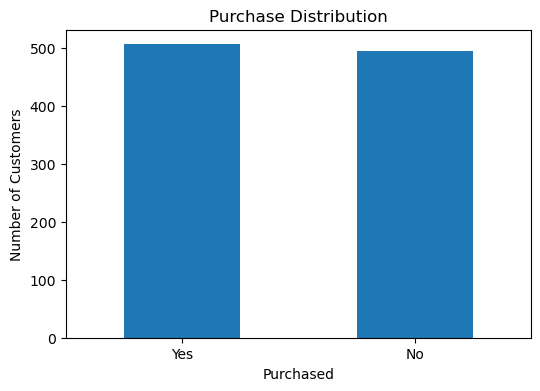


Numerical Columns Used for EDA:
['Age', 'Salary', 'Experience_Years', 'Rating']


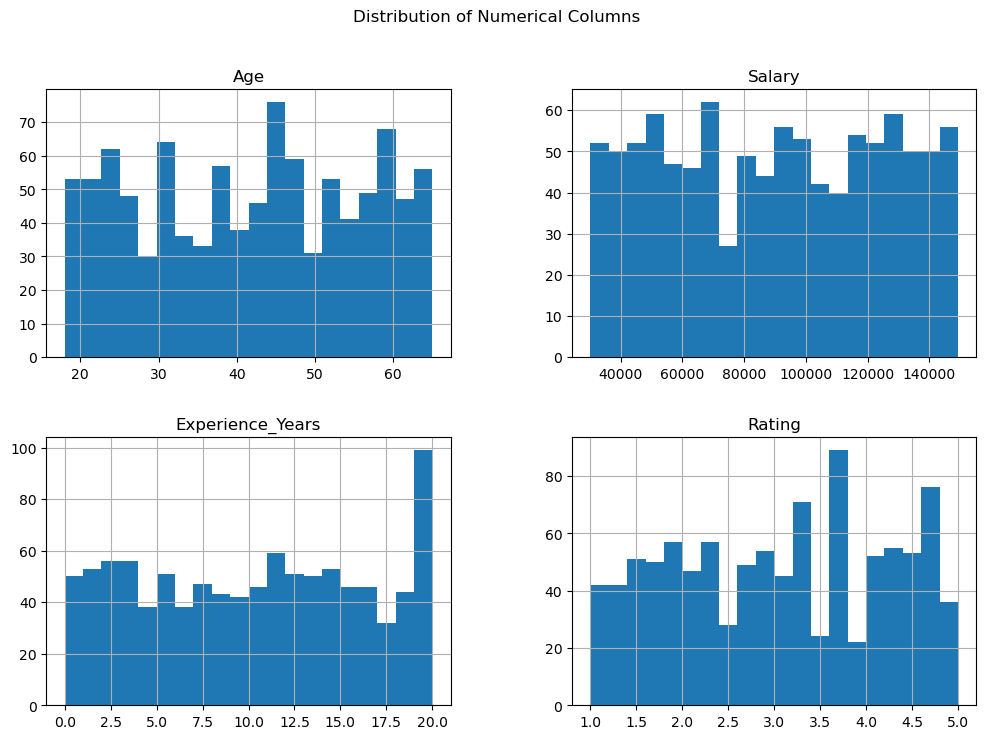

In [47]:
# EDA - purchase distribution and numerical columns

target_column = "Purchased"

print("Target Column:", target_column)
print("\nTarget Value Counts:")
print(df[target_column].value_counts())

print("\nTarget Percentage:")
print(round(df[target_column].value_counts(normalize=True) * 100, 2))

# Purchase distribution chart
plt.figure(figsize=(6, 4))
df[target_column].value_counts().plot(kind="bar")
plt.title("Purchase Distribution")
plt.xlabel("Purchased")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# Numerical columns distribution
numerical_columns = ["Age", "Salary", "Experience_Years", "Rating"]

print("\nNumerical Columns Used for EDA:")
print(numerical_columns)

df[numerical_columns].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution of Numerical Columns")
plt.show()

Product Category Counts:
Product_Category
Books          209
Clothing       206
Sports         197
Electronics    195
Food           193
Name: count, dtype: int64


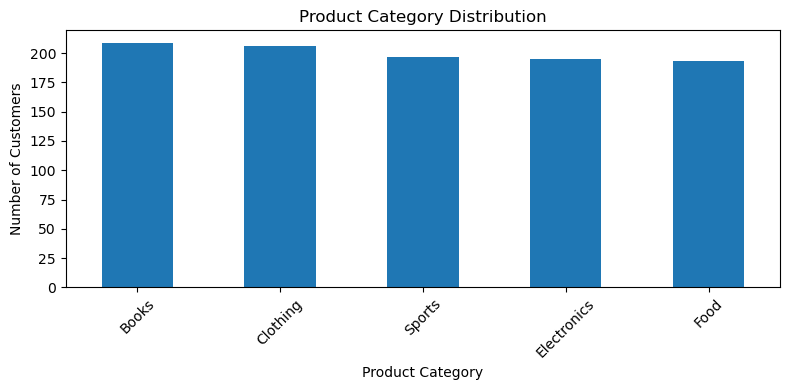


Correlation Table:


,Age,Salary,Experience_Years,Rating
Age,1.000000,-0.010720,0.006505,0.033260
Salary,-0.010720,1.000000,-0.008802,-0.001160
Experience_Years,0.006505,-0.008802,1.000000,0.015298
Rating,0.033260,-0.001160,0.015298,1.000000


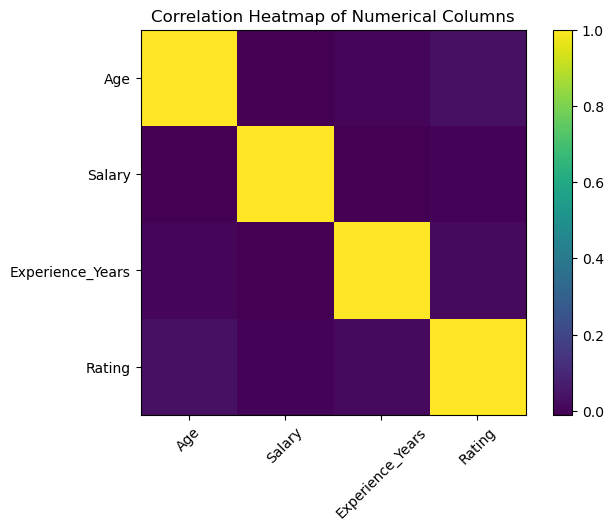

In [48]:
# EDA - product category and correlation heatmap

# Product category distribution
print("Product Category Counts:")
print(df["Product_Category"].value_counts())

plt.figure(figsize=(8, 4))
df["Product_Category"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap
correlation = df[["Age", "Salary", "Experience_Years", "Rating"]].corr()

print("\nCorrelation Table:")
display(correlation)

plt.figure(figsize=(7, 5))
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

In [ ]:
# Data preparation steps

# Remove columns that are not useful for clear model explanation
# Customer_ID and Name are identifiers
# City and Job_Title have too many unique values, so they make the tree harder to explain

X = df.drop(["Customer_ID", "Name", "City", "Job_Title", "Purchased"], axis=1)
y = df["Purchased"]

print("Data Preparation Step")
print("Target column: Purchased")

print("\nRemoved columns:")
print("Customer_ID - only an ID number")
print("Name - personal identifier")
print("City - too many unique values")
print("Job_Title - too many unique values")

print("\nInput columns used for prediction:")
print(X.columns)

print("\nTarget value counts:")
print(y.value_counts())

# Convert categorical column into numeric form
X_encoded = pd.get_dummies(X, drop_first=True)

print("\nBefore encoding:", X.shape)
print("After encoding:", X_encoded.shape)

print("\nFirst 5 rows after encoding:")
display(X_encoded.head())

Data Preparation Step
Target column: Purchased

Removed columns:
Customer_ID - only an ID number
Name - personal identifier
City - too many unique values
Job_Title - too many unique values

Input columns used for prediction:
Index(['Product_Category', 'Age', 'Salary', 'Experience_Years', 'Rating'], dtype='str')

Target value counts:
Purchased
Yes    506
No     494
Name: count, dtype: int64

Before encoding: (1000, 5)
After encoding: (1000, 8)

First 5 rows after encoding:


,Age,Salary,Experience_Years,Rating,Product_Category_Clothing,Product_Category_Electronics,Product_Category_Food,Product_Category_Sports
0,57,148373,7,3.6,False,False,False,True
1,41,67904,10,2.4,False,True,False,False
2,56,84471,5,3.2,False,False,True,False
3,55,53871,11,1.7,False,False,False,True
4,34,111193,11,1.7,True,False,False,False


In [ ]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Train-Test Split Completed
Training set: (700, 8)
Testing set: (300, 8)

Training target distribution:
Purchased
Yes    354
No     346
Name: count, dtype: int64

Testing target distribution:
Purchased
Yes    152
No     148
Name: count, dtype: int64


Decision Tree model developed and trained successfully.
Algorithm used: Decision Tree Classifier
Criterion used: Entropy
Maximum depth of tree: 3
Number of leaf nodes: 7


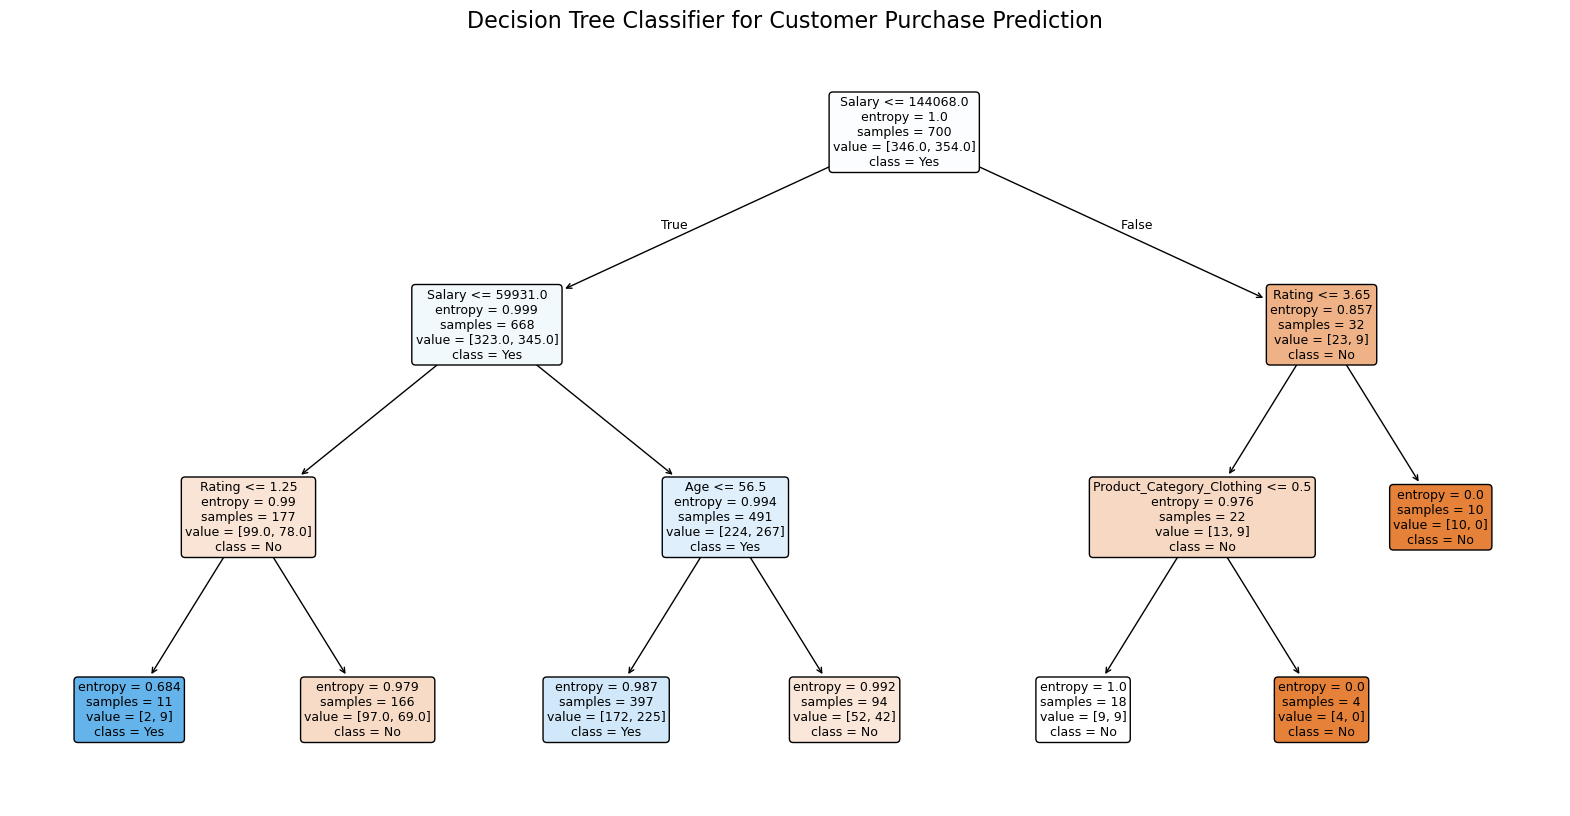

In [ ]:
# Model Development - Create, Train, and Display Decision Tree

clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)

print("Decision Tree model developed and trained successfully.")
print("Algorithm used: Decision Tree Classifier")
print("Criterion used: Entropy")
print("Maximum depth of tree:", clf.get_depth())
print("Number of leaf nodes:", clf.get_n_leaves())

plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=X_encoded.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier for Customer Purchase Prediction", fontsize=16)
plt.show()

In [ ]:
# Model Evaluation - Prediction and Confusion Matrix Values

y_pred = clf.predict(X_test)

print("First 10 Actual Values:")
print(list(y_test.head(10)))

print("\nFirst 10 Predicted Values:")
print(list(y_pred[:10]))

cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])

print("\nConfusion Matrix:")
print(cm)

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("\nConfusion Matrix Values:")
print("True Negative  (Actual No, Predicted No):", TN)
print("False Positive (Actual No, Predicted Yes):", FP)
print("False Negative (Actual Yes, Predicted No):", FN)
print("True Positive  (Actual Yes, Predicted Yes):", TP)

First 10 Actual Values:
['Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No']

First 10 Predicted Values:
['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No']

Confusion Matrix:
[[61 87]
 [62 90]]

Confusion Matrix Values:
True Negative  (Actual No, Predicted No): 61
False Positive (Actual No, Predicted Yes): 87
False Negative (Actual Yes, Predicted No): 62
True Positive  (Actual Yes, Predicted Yes): 90


In [62]:
# Accuracy Calculation

total_predictions = TP + TN + FP + FN
correct_predictions = TP + TN

accuracy = correct_predictions / total_predictions

print("Accuracy Calculation")
print("Accuracy = Correct Predictions / Total Predictions")
print("Correct Predictions = TP + TN =", TP, "+", TN, "=", correct_predictions)
print("Total Predictions = TP + TN + FP + FN =", total_predictions)

print("\nAccuracy Score:", round(accuracy, 4))
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

print("Accuracy shows the overall percentage of correct predictions. In this customer purchase problem, it tells how many total Yes and No predictions were correct.")

Accuracy Calculation
Accuracy = Correct Predictions / Total Predictions
Correct Predictions = TP + TN = 90 + 61 = 151
Total Predictions = TP + TN + FP + FN = 300

Accuracy Score: 0.5033
Accuracy Percentage: 50.33 %
Accuracy shows the overall percentage of correct predictions. In this customer purchase problem, it tells how many total Yes and No predictions were correct.


In [63]:
# Precision and Recall Calculation

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

print("Precision Calculation")
print("Precision = TP / (TP + FP)")
print("Precision =", TP, "/ (", TP, "+", FP, ")")
print("Precision Score:", round(precision, 4))
print("Precision Percentage:", round(precision * 100, 2), "%")

print("The precision evaluation shows how many customers predicted as buyers were actually buyers. For business, higher precision means fewer wrong customers are targeted as likely buyers.")

print("\n" + "-"*60)

print("\nRecall Calculation")
print("Recall = TP / (TP + FN)")
print("Recall =", TP, "/ (", TP, "+", FN, ")")
print("Recall Score:", round(recall, 4))
print("Recall Percentage:", round(recall * 100, 2), "%")

print("The recall evaluation shows how many actual buyers the model correctly found. For business, higher recall means the model misses fewer real potential buyers.")

Precision Calculation
Precision = TP / (TP + FP)
Precision = 90 / ( 90 + 87 )
Precision Score: 0.5085
Precision Percentage: 50.85 %
The precision evaluation shows how many customers predicted as buyers were actually buyers. For business, higher precision means fewer wrong customers are targeted as likely buyers.

------------------------------------------------------------

Recall Calculation
Recall = TP / (TP + FN)
Recall = 90 / ( 90 + 62 )
Recall Score: 0.5921
Recall Percentage: 59.21 %
The recall evaluation shows how many actual buyers the model correctly found. For business, higher recall means the model misses fewer real potential buyers.


In [65]:
# F1-Score and Final Evaluation Table
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
print("F1-Score Calculation")
print("F1-Score = 2 × (Precision × Recall) / (Precision + Recall)")
print("F1-Score = 2 × (", round(precision, 4), "×", round(recall, 4), ") / (", round(precision, 4), "+", round(recall, 4), ")")
print("\nF1-Score:", round(f1, 4))
print("F1-Score Percentage:", round(f1 * 100, 2), "%")

print("F1-Score balances precision and recall. It is useful because the business needs both correct buyer predictions and fewer missed buyers.")
evaluation_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1],
    "Percentage": [
        round(accuracy * 100, 2),
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(f1 * 100, 2)
    ]
})

print("\nFinal Model Evaluation Table:")
display(evaluation_table)

F1-Score Calculation
F1-Score = 2 × (Precision × Recall) / (Precision + Recall)
F1-Score = 2 × ( 0.5085 × 0.5921 ) / ( 0.5085 + 0.5921 )

F1-Score: 0.5471
F1-Score Percentage: 54.71 %
F1-Score balances precision and recall. It is useful because the business needs both correct buyer predictions and fewer missed buyers.

Final Model Evaluation Table:


,Metric,Score,Percentage
0,Accuracy,0.503333,50.33
1,Precision,0.508475,50.85
2,Recall,0.592105,59.21
3,F1-Score,0.547112,54.71


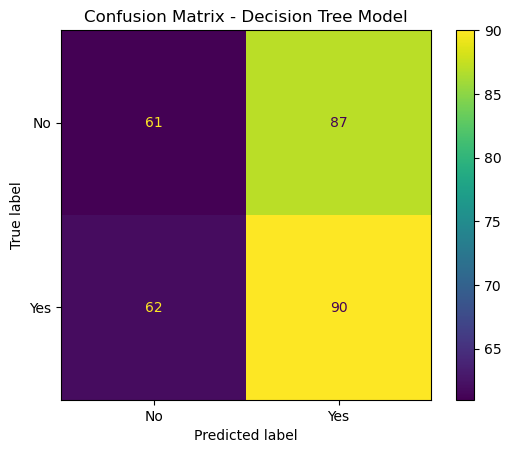

The confusion matrix shows correct and incorrect predictions for both No and Yes classes. True Negative means actual non-buyers were correctly predicted as non-buyers.
True Positive means actual buyers were correctly predicted as buyers. False Positive means non-buyers were wrongly predicted as buyers.
False Negative means buyers were wrongly predicted as non-buyers.


In [67]:
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)
disp.plot()
plt.title("Confusion Matrix - Decision Tree Model")
plt.show()

print("The confusion matrix shows correct and incorrect predictions for both No and Yes classes. True Negative means actual non-buyers were correctly predicted as non-buyers.")
print("True Positive means actual buyers were correctly predicted as buyers. False Positive means non-buyers were wrongly predicted as buyers.")
print("False Negative means buyers were wrongly predicted as non-buyers.")